<a href="https://colab.research.google.com/github/PaulAndre1/PhawAI-s-Projects/blob/main/Competencia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from itertools import product
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [3]:
train = pd.read_csv('/content/drive/MyDrive/PhawAI Kaggle competencia/train.csv')
test_public = pd.read_csv('/content/drive/MyDrive/PhawAI Kaggle competencia/test_public.csv')
test_private = pd.read_csv('/content/drive/MyDrive/PhawAI Kaggle competencia/test_private.csv')

In [ ]:
def check_missing_data(df):
  plt.figure(figsize=(12, 6))
  sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
  plt.title('Mapa de Elementos Faltantes en el Dataset')
  plt.show()


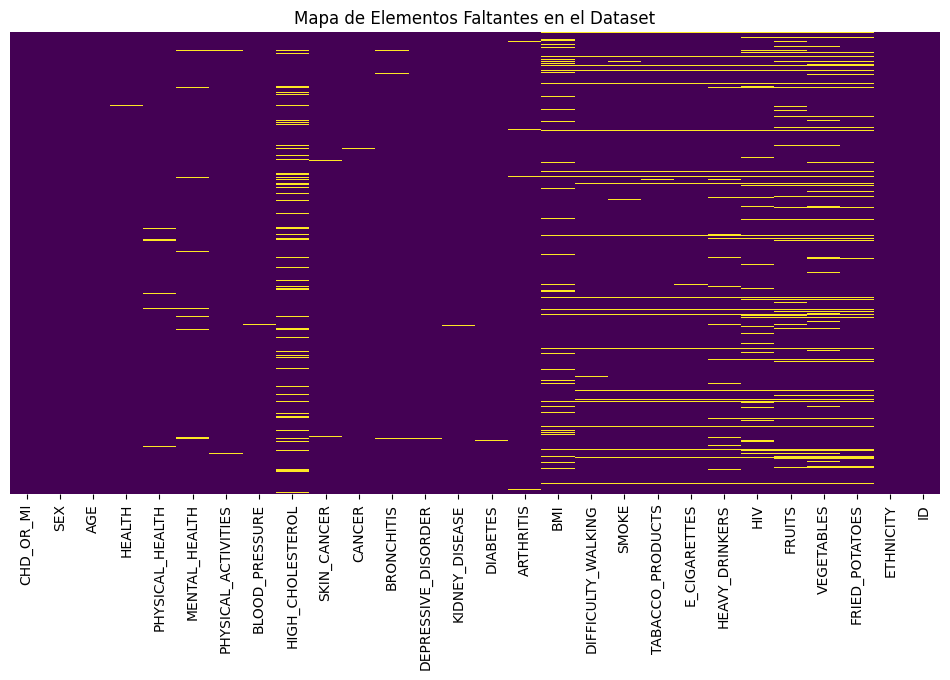

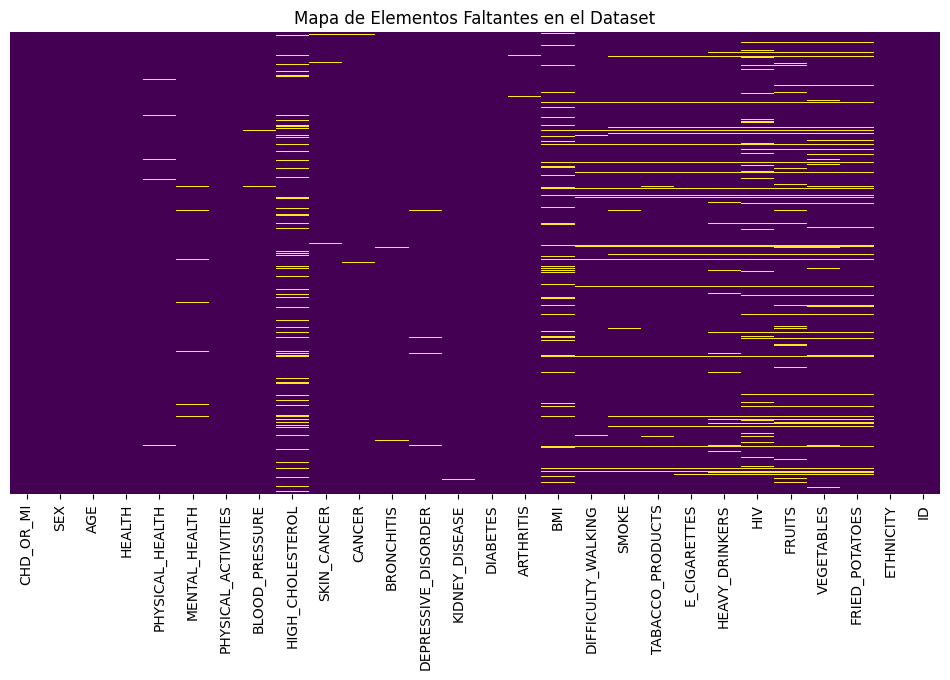

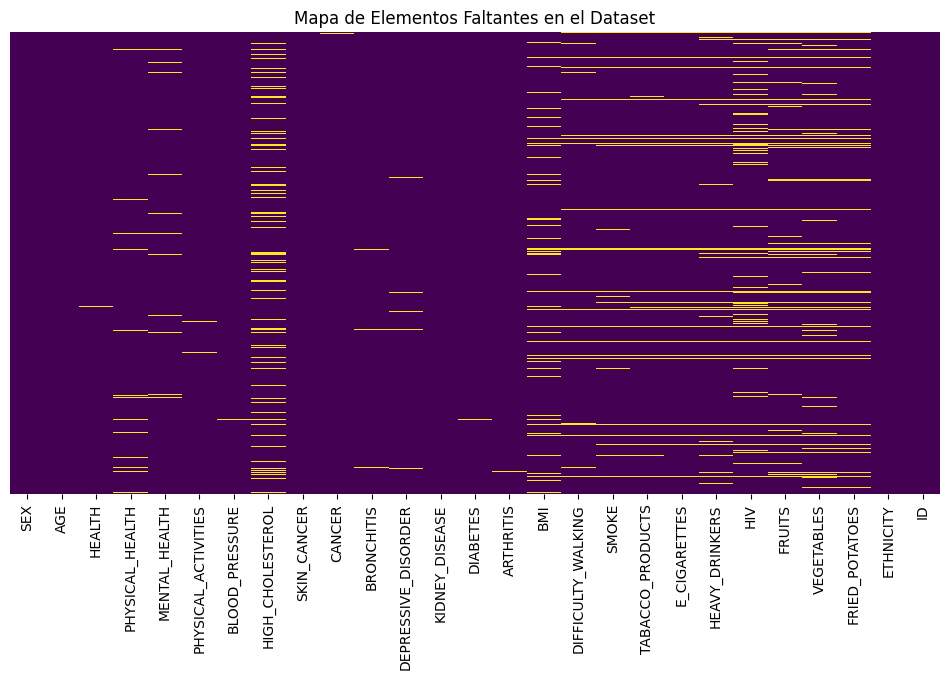

In [ ]:
check_missing_data(train)
check_missing_data(test_public)
check_missing_data(test_private)

Los tres datasets tienen elementos faltantes

In [ ]:
train.columns

Index(['CHD_OR_MI', 'SEX', 'AGE', 'HEALTH', 'PHYSICAL_HEALTH', 'MENTAL_HEALTH',
       'PHYSICAL_ACTIVITIES', 'BLOOD_PRESSURE', 'HIGH_CHOLESTEROL',
       'SKIN_CANCER', 'CANCER', 'BRONCHITIS', 'DEPRESSIVE_DISORDER',
       'KIDNEY_DISEASE', 'DIABETES', 'ARTHRITIS', 'BMI', 'DIFFICULTY_WALKING',
       'SMOKE', 'TABACCO_PRODUCTS', 'E_CIGARETTES', 'HEAVY_DRINKERS', 'HIV',
       'FRUITS', 'VEGETABLES', 'FRIED_POTATOES', 'ETHNICITY', 'ID'],
      dtype='object')

In [4]:
categorical_columns = ['CHD_OR_MI', 'SEX', 'HEALTH', 'PHYSICAL_HEALTH', 'MENTAL_HEALTH',
       'PHYSICAL_ACTIVITIES', 'BLOOD_PRESSURE', 'HIGH_CHOLESTEROL',
       'SKIN_CANCER', 'CANCER', 'BRONCHITIS', 'DEPRESSIVE_DISORDER',
       'KIDNEY_DISEASE', 'DIABETES', 'ARTHRITIS', 'DIFFICULTY_WALKING',
       'SMOKE', 'TABACCO_PRODUCTS', 'E_CIGARETTES', 'HEAVY_DRINKERS', 'HIV',
       'FRUITS', 'VEGETABLES', 'FRIED_POTATOES', 'ETHNICITY']

numerical_columns = ['BMI', 'AGE']

Se intento hacer ingenieria de datos fusionando varias columnas, sin exito.
Por ello se decidio omitir el paso

In [5]:
def process_data(df):
  df_copy = df.copy()

  #Data imputation
  for col in categorical_columns:
      if col in df_copy.columns:
          moda = df_copy[col].mode()[0]
          df_copy[col].fillna(moda, inplace=True)

  for col in numerical_columns:
      if col in df_copy.columns:
          mean_value = df_copy[col].mean()
          df_copy[col].fillna(mean_value, inplace=True)
  """
  #Data engineering ==================================================================

  #Drop some columns with low correlation
  df_copy.drop(['TABACCO_PRODUCTS', 'E_CIGARETTES'] , axis=1, inplace=True)

  #Merge FRUITS and VEGETABLES
  df_copy["HEALTHY_FOOD"] = np.where(df_copy["FRUITS"] == df_copy["VEGETABLES"], 1, 0)

  df_copy.drop(['FRUITS', 'VEGETABLES'], axis=1, inplace=True)

  #Merge CANCER and SKIN_CANCER
  df_copy["HAVE_CANCER"] = np.where(df_copy["SKIN_CANCER"] == df_copy["CANCER"], 1, 0)

  df_copy.drop(['SKIN_CANCER', 'CANCER'], axis=1, inplace=True)


  #Merge MENTAL_HEALTH and DEPRESSIVE_DISORDER
  df_copy["MENTAL_INDICATOR"] = (df_copy[["MENTAL_HEALTH",
                                      "DEPRESSIVE_DISORDER"]]).sum(axis = 1)
  df_copy.drop(['MENTAL_HEALTH', 'DEPRESSIVE_DISORDER'] , axis=1, inplace=True)

  # Función para categorizar el IMC
  def categorizar_imc(imc):
      if imc < 18.5:
          return 1  # Bajo peso
      elif 18.5 <= imc < 24.9:
          return 2  # Peso saludable
      elif 25 <= imc < 29.9:
          return 3  # Sobrepeso
      else:
          return 4  # Obesidad

  # Aplicar la función al DataFrame
  df_copy['categoria_BMI'] = df['BMI'].apply(categorizar_imc)
  df_copy.drop(['BMI'] , axis=1, inplace=True)
  """
  return df_copy

In [ ]:
data_train = process_data(train)
data_test_public = process_data(test_public)
data_test_private = process_data(test_private)

In [ ]:
for column in train.columns:
  print("=====================")
  print(train[column].value_counts())

CHD_OR_MI
1.0    318988
0.0     28258
Name: count, dtype: int64
SEX
2    185970
1    161276
Name: count, dtype: int64
AGE
80    26897
65     8024
70     7822
67     7526
60     7475
      ...  
22     3053
24     3049
20     2870
19     2776
18     2609
Name: count, Length: 63, dtype: int64
HEALTH
1.0    289523
2.0     56885
Name: count, dtype: int64
PHYSICAL_HEALTH
1.0    228286
2.0     71772
3.0     39882
Name: count, dtype: int64
MENTAL_HEALTH
1.0    214722
2.0     82849
3.0     43641
Name: count, dtype: int64
PHYSICAL_ACTIVITIES
1.0    262398
2.0     84195
Name: count, dtype: int64
BLOOD_PRESSURE
1.0    210318
2.0    135621
Name: count, dtype: int64
HIGH_CHOLESTEROL
2.0    178719
1.0    118336
Name: count, dtype: int64
SKIN_CANCER
2.0    314042
1.0     32337
Name: count, dtype: int64
CANCER
2.0    312945
1.0     33509
Name: count, dtype: int64
BRONCHITIS
2.0    319252
1.0     26681
Name: count, dtype: int64
DEPRESSIVE_DISORDER
2.0    277982
1.0     67578
Name: count, dtype: int64
K

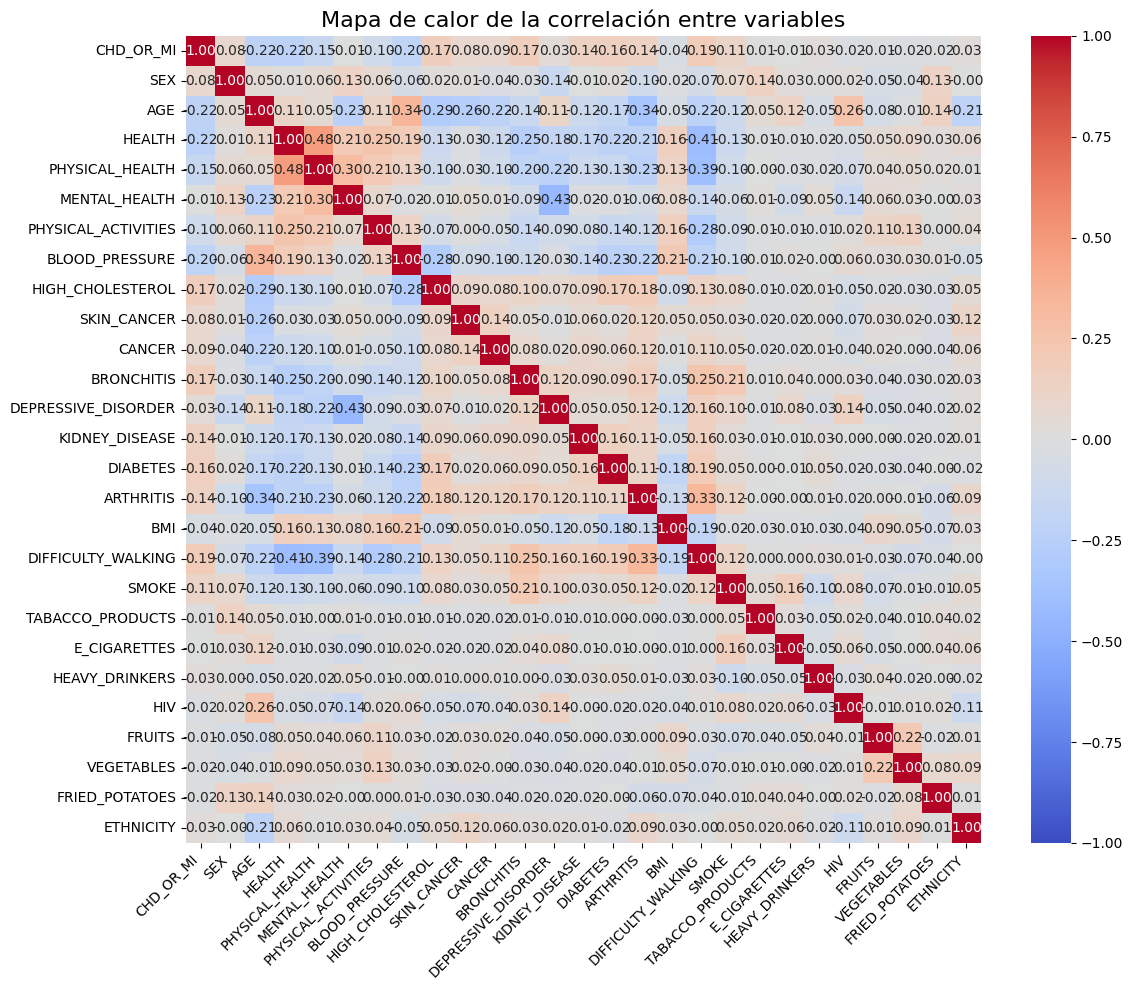

In [ ]:
# Calcular la matriz de correlación
train_copy = train.copy()
train_copy = train_copy.dropna()
train_copy.drop(['ID'], axis=1, inplace=True)
correlation_matrix = train_copy.corr()

# Crear un mapa de calor (heatmap) de la matriz de correlación
plt.figure(figsize=(12, 10))  # Ajustar el tamaño del gráfico
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)

# Títulos y etiquetas
plt.title("Mapa de calor de la correlación entre variables", fontsize=16)
plt.xticks(rotation=45, ha='right')  # Rotar etiquetas del eje X
plt.yticks(rotation=0)  # Mantener etiquetas del eje Y horizontales

# Mostrar el gráfico
plt.tight_layout()
plt.show()


Se realizo un sobremuestreo de la clase minoritaria al 20% de la clase mayoritaria para compensar el desbalanceo, lo que arrojo buenos resultados.

Se intento usar el dataset "test_public.csv" para entrenamiento y que el modelo sea capaz de generalizar mejor al tener más datos, sin embargo, esto carece de una metrica para poder ver el desempeño real del modelo al momento de generalizar con instancias que no ha visto durante su entrenamiento, al final, el modelo escogido fue el *22* sin embargo el mejor era el *13* (corroborado en el score final de la competencia de kaggle), esta decición se hizo en base al entrenamiento sin usar "test_public.csv", una de las soluciones que se mando y que afortunadamente no elegi para el score final fue el de el modelo *24* que hacia overfitting a los datos de entrenamiento.

RESUMEN DE RESULTADOS FINALES PARA EL MODELO USADO:

PRIVADO = 0.95760

PÚBLICO = 0.95839

RESUMEN DE RESULTADOS FINALES PARA EL MEJOR MODELO:

PRIVADO = 0.95763

PÚBLICO = 0.95813

por lo que "0.95763" será mi respuesta en el formulario de postulación

Los resultados de todas mis submissions se detallan a continuación en:

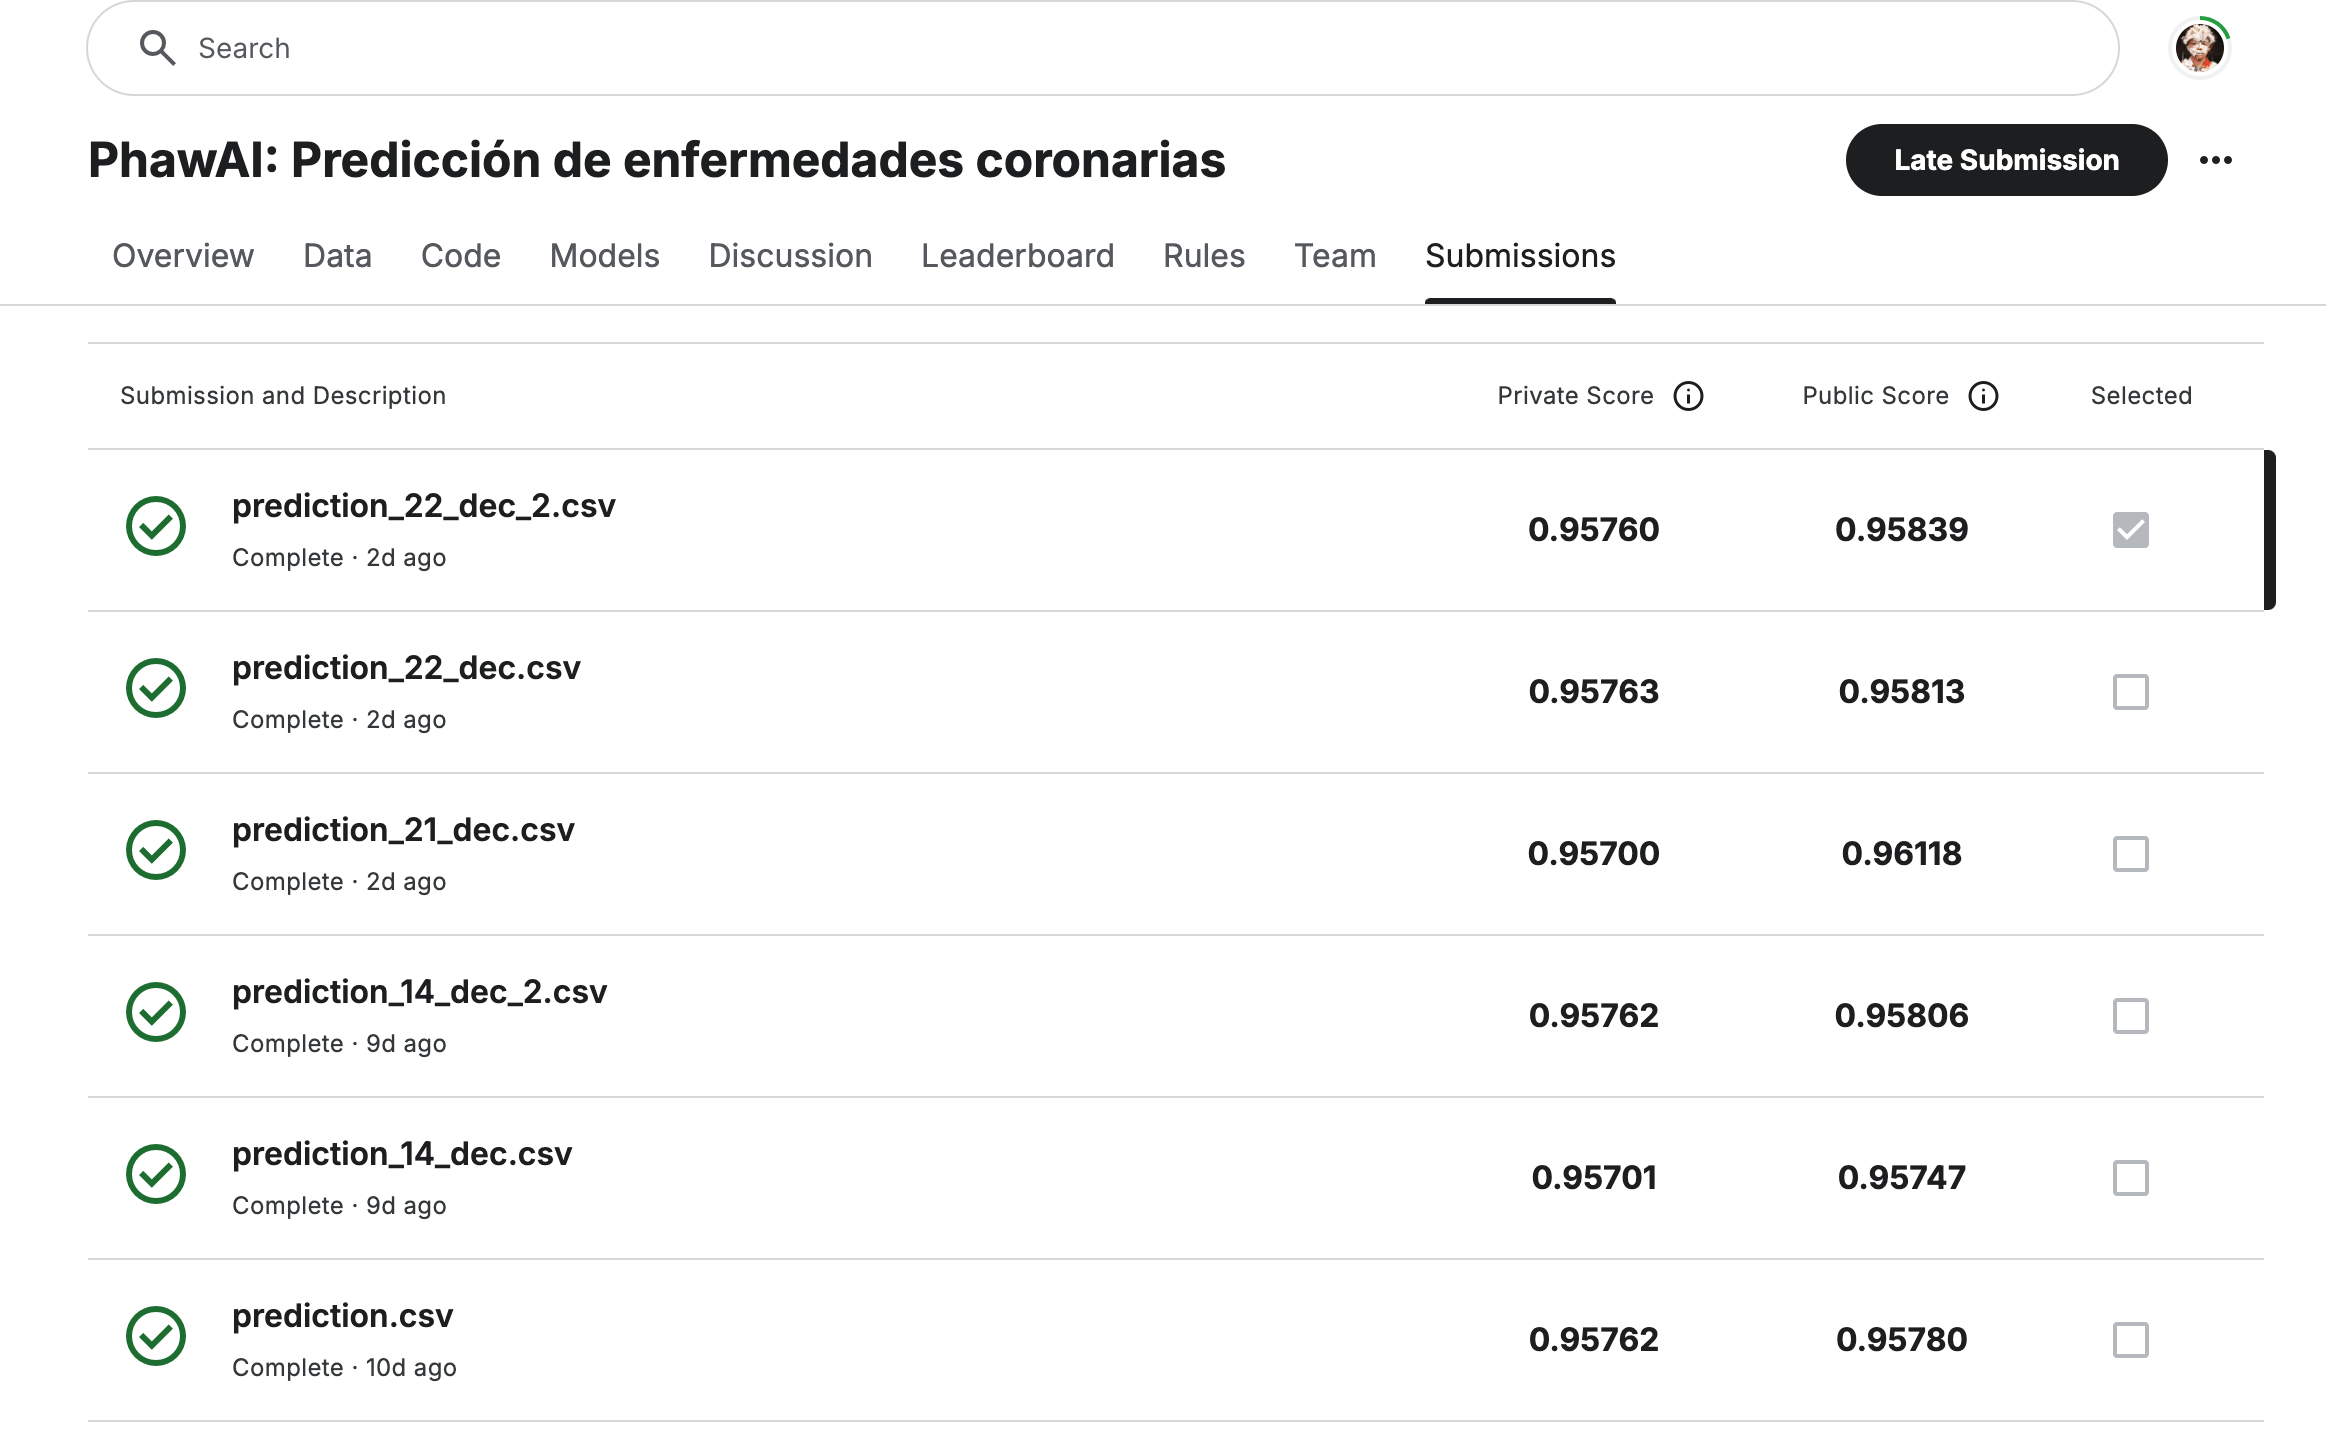

In [7]:
X_train = data_train.drop(['CHD_OR_MI', 'ID'], axis=1)
y_train = data_train['CHD_OR_MI']

X_test = data_test_public.drop(['CHD_OR_MI', 'ID'], axis=1)
y_test = data_test_public['CHD_OR_MI']

X_private = data_test_private.drop(['ID'], axis=1)

X_to_kaggle = pd.concat([X_train, X_test], axis=0, ignore_index=True)
y_to_kaggle = pd.concat([y_train, y_test], axis=0, ignore_index=True)

# Aplicar SMOTE para el sobremuestreo de la clase minoritaria (a un x% del tamaño de la clase mayoritaria)
smote = SMOTE(sampling_strategy=0.20, random_state=42)  # x% de la clase mayoritaria
X_train_resampled, y_train_resampled = smote.fit_resample(X_to_kaggle, y_to_kaggle)

# Modelos y sus hiperparámetros
search_space = {
    "XGBoost": {
        "model": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        "params": {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [3, 5, 7]
        }
    }
}

# Realizar Grid Search manual
results = []
f1_best = 0
best_model = None

for model_name, model_info in search_space.items():
    model = model_info["model"]
    params = model_info["params"]

    # Crear combinaciones de hiperparámetros manualmente
    param_combinations = list(product(*params.values()))
    param_keys = list(params.keys())

    count = 0

    for combination in param_combinations:
        # Configurar el modelo con los hiperparámetros actuales
        param_dict = dict(zip(param_keys, combination))
        model.set_params(**param_dict)

        # Entrenar el modelo
        model.fit(X_train_resampled, y_train_resampled)

        # Realizar predicciones
        y_pred = model.predict(X_test)
        y_pred_train = model.predict(X_train)

        # Calcular F1 Score
        f1 = f1_score(y_test, y_pred)  # Ajusta el 'average' según el problema

        if count == 22:

            print(f"F1 al {count} con {combination}")
            f1_best = f1
            best_model = model
            prediction_public = data_test_public[['ID']]
            prediction_public['CHD_OR_MI'] = y_pred

            y_pred_private = model.predict(X_private)
            prediction_private = data_test_private[['ID']]
            prediction_private['CHD_OR_MI'] = y_pred_private
        count += 1
        # Mostrar la combinación actual y el F1 Score
        print(f"Model: {model_name}, Params: {param_dict}, F1 Score: {f1}")

        # Guardar resultados
        results.append({
            "Model": model_name,
            "Params": param_dict,
            "F1 Score": f1
        })

# Ordenar y mostrar los resultados finales
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False)
print("\nResultados finales:")
print(results_df)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [05:41:11] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warni

Model: XGBoost, Params: {'n_estimators': 50, 'learning_rate': 0.01, 'max_depth': 3}, F1 Score: 0.9575888568683958


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [05:41:14] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Model: XGBoost, Params: {'n_estimators': 50, 'learning_rate': 0.01, 'max_depth': 5}, F1 Score: 0.9575888568683958


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [05:41:23] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


...

Model: XGBoost, Params: {'n_estimators': 200, 'learning_rate': 0.2, 'max_depth': 3}, F1 Score: 0.9580722658843698


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [05:45:49] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Model: XGBoost, Params: {'n_estimators': 200, 'learning_rate': 0.2, 'max_depth': 5}, F1 Score: 0.958864391422531


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [05:46:05] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Model: XGBoost, Params: {'n_estimators': 200, 'learning_rate': 0.2, 'max_depth': 7}, F1 Score: 0.961147667892394

Resultados finales:
      Model                                             Params  F1 Score
26  XGBoost  {'n_estimators': 200, 'learning_rate': 0.2, 'm...  0.961148
23  XGBoost  {'n_estimators': 200, 'learning_rate': 0.1, 'm...  0.959592
17  XGBoost  {'n_estimators': 100, 'learning_rate': 0.2, 'm...  0.959288
25  XGBoost  {'n_estimators': 200, 'learning_rate': 0.2, 'm...  0.958864
14  XGBoost  {'n_estimators': 100, 'learning_rate': 0.1, 'm...  0.958644
8   XGBoost  {'n_estimators': 50, 'learning_rate': 0.2, 'ma...  0.958453
16  XGBoost  {'n_estimators': 100, 'learning_rate': 0.2, 'm...  0.958446
22  XGBoost  {'n_estimators': 200, 'learning_rate': 0.1, 'm...  0.958397
13  XGBoost  {'n_estimators': 100, 'learning_rate': 0.1, 'm...  0.958160
21  XGBoost  {'n_estimators': 200, 'learning_rate': 0.1, 'm...  0.958130
24  XGBoost  {'n_estimators': 200, 'learning_rate': 0.2, 'm... 

In [8]:
df_combined = pd.concat([prediction_public, prediction_private], axis=0, ignore_index=True)
df_combined.to_csv('prediction_22_dec_2.csv', index=False)